In [18]:
from md_Helpers.dt_validation import run_thermalization_dt_sweep

sweep = run_thermalization_dt_sweep(
    n_fcc_cells=30,
    target_rho=0.8,
    kT=1.00,
    timesteps=[0.0001, 0.001, 0.0015, 0.002, 0.0025, 0.005],
    physical_time=3000.0,  # equivalent to 1,000,000 steps at dt=0.005
    seeds=[1, 2, 3, 4, 5],
    log_interval=5.0,
)


#######
# dt = 0.0001 and dt = 0.001 are the same

###
# dt = 0.005 most likely too high



## 0.0025, 0.002, 


########
#Need to rerun this
#Failed at dt = 0.1, dt = 0.05, 0.015 has bad plots and so does .01 and .0075

print("Manifest:", sweep["manifest_path"])

for run in sweep["runs"]:
    print(run["dt"], run["seed"], run["status"], run["log_path"])

Loaded existing FCC lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices_v3/FCC/n_cells_30/rho_0.800/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f2eea53f1d0>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Validation/Thermalization_dt_test_v1/FCC/n_cells_30/rho_0.800/kT_1.000/physical_time_3000.000/dt_0.00500/seed_5/thermalization_log.hdf5
Log period: 1000
Stopped HDF5 logger
Wrote HDF5 metadata
Log file: /exp/e961/data/MDsims-data/pnichols/Validation/Thermalization_dt_test_v1/FCC/n_cells_30/rho_0.800/kT_1.000/physical_time_3000.000/dt_0.00500/seed_5/thermalization_log.hdf5
Metadata group: metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Validation/Thermalization_dt_test_v1/FCC/n_cells_30/rho_0.800/kT_1.000/physical_time_3000.000/dt_0.00500/seed_5/thermalized_final.gsd
Manifest: /exp/e961/data/MDsims-data/pnichols/Validation/Thermalization_dt_test_v1/FCC/n_cells_30/rho_0.800/kT_1.000/physical_time_3000.000/

In [19]:
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

manifest_path = Path(
    "/exp/e961/data/MDsims-data/pnichols/Validation/"
    "Thermalization_dt_test_v1/FCC/n_cells_30/"
    "rho_0.800/kT_1.000/physical_time_3000.000/"
    "sweep_manifest.json"
)

with manifest_path.open() as f:
    manifest = json.load(f)

thermo_path = "hoomd-data/md/compute/ThermodynamicQuantities"
records = []

for run in manifest["runs"]:
    log_path = Path(run["log_path"])
    if not log_path.exists():
        continue

    dt = float(run["dt"])
    seed = int(run["seed"])

    with h5py.File(log_path, "r") as hdf:
        steps = hdf["hoomd-data/Simulation/timestep"][:]
        temperature = hdf[f"{thermo_path}/kinetic_temperature"][:]
        pressure = hdf[f"{thermo_path}/pressure"][:]
        potential_energy = hdf[f"{thermo_path}/potential_energy"][:]
        N = int(hdf["metadata/state"].attrs["N"])

    for t, T, P, U in zip(
        steps * dt, temperature, pressure, potential_energy / N
    ):
        records.append({
            "time": t,
            "dt": dt,
            "seed": seed,
            "temperature": T,
            "pressure": P,
            "potential_energy_per_particle": U,
        })

df = pd.DataFrame(records)

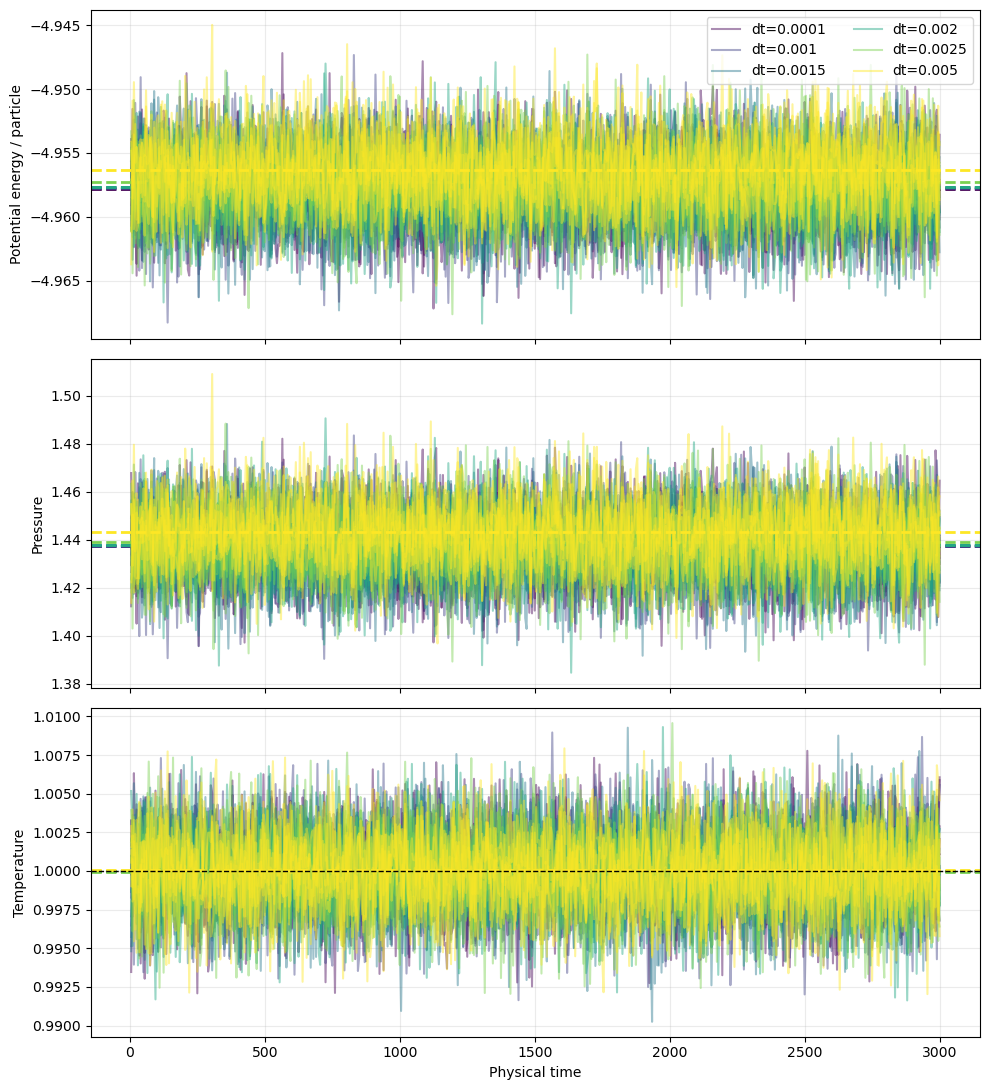

In [20]:
quantities = [
    ("potential_energy_per_particle", "Potential energy / particle"),
    ("pressure", "Pressure"),
    ("temperature", "Temperature"),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

colors = plt.cm.viridis(
    np.linspace(0, 1, df["dt"].nunique())
)

for color, (dt, group) in zip(colors, df.groupby("dt")):
    for seed, run in group.groupby("seed"):
        run_plot = run.sort_values("time").iloc[::1]

        axes[0].plot(
            run_plot["time"],
            run_plot["potential_energy_per_particle"],
            color=color,
            alpha=0.45,
            label=f"dt={dt:g}" if seed == group["seed"].min() else None,
        )
        axes[1].plot(
            run_plot["time"],
            run_plot["pressure"],
            color=color,
            alpha=0.45,
        )
        axes[2].plot(
            run_plot["time"],
            run_plot["temperature"],
            color=color,
            alpha=0.45,
        )

    axes[0].axhline(
        group["potential_energy_per_particle"].mean(),
        color=color,
        linestyle="--",
        linewidth=2,
    )
    axes[1].axhline(
        group["pressure"].mean(),
        color=color,
        linestyle="--",
        linewidth=2,
    )
    axes[2].axhline(
        group["temperature"].mean(),
        color=color,
        linestyle="--",
        linewidth=2,
    )

for ax, (_, label) in zip(axes, quantities):
    ax.set_ylabel(label)
    ax.grid(alpha=0.25)

axes[2].axhline(
    1.00,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Target temperature",
)

axes[0].legend(ncol=2)
axes[-1].set_xlabel("Physical time")

plt.tight_layout()

,dt,seed,temperature,potential_energy_per_particle,pressure
0,0.0001,1,1.000143,-4.958041,1.436202
1,0.0001,2,1.000236,-4.957587,1.439079
2,0.0001,3,0.999991,-4.957628,1.437818
3,0.0001,4,1.000102,-4.957928,1.437185
4,0.0001,5,0.999924,-4.957980,1.436354
5,0.0010,1,0.999835,-4.957892,1.436588
6,0.0010,2,0.999736,-4.957338,1.439431
7,0.0010,3,0.999862,-4.957558,1.437817
8,0.0010,4,1.000211,-4.957597,1.438632
9,0.0010,5,1.000053,-4.957984,1.436277


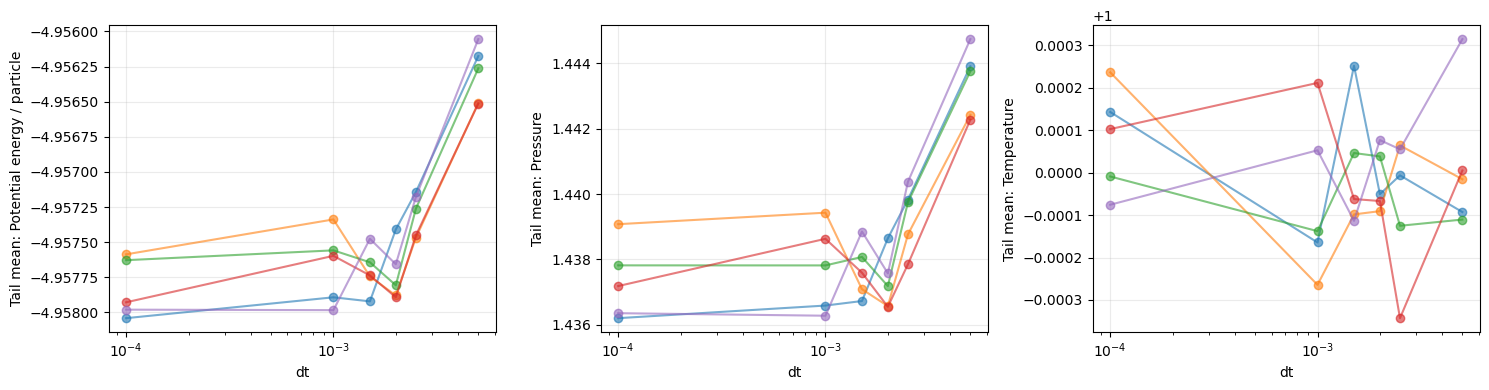

In [21]:
tail = df[df["time"] >= 0.5 * df["time"].max()]

run_means = (
    tail.groupby(["dt", "seed"])
    [["temperature", "potential_energy_per_particle", "pressure"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (quantity, label) in zip(axes, quantities):
    for seed, values in run_means.groupby("seed"):
        ax.plot(values["dt"], values[quantity], "o-", alpha=0.6)

    ax.set_xscale("log")
    ax.set_xlabel("dt")
    ax.set_ylabel(f"Tail mean: {label}")
    ax.grid(alpha=0.25)

plt.tight_layout()
display(run_means)